In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
df = pd.read_csv('/content/drive/MyDrive/superstore.csv', encoding="cp1252")

print ("HEAD OF DATA\n")
df.head(5)

HEAD OF DATA



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
column_names = df.columns.tolist()
print(column_names)

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


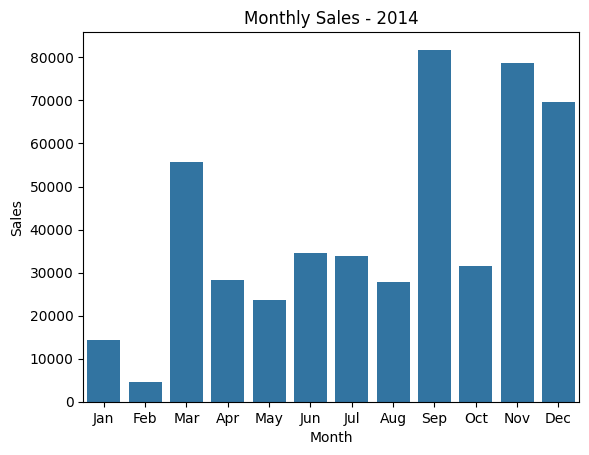

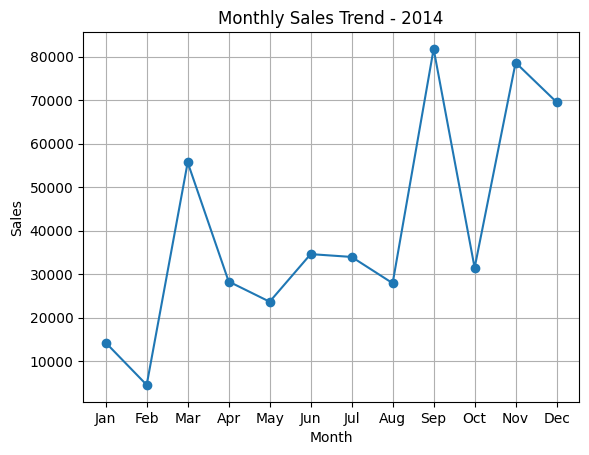

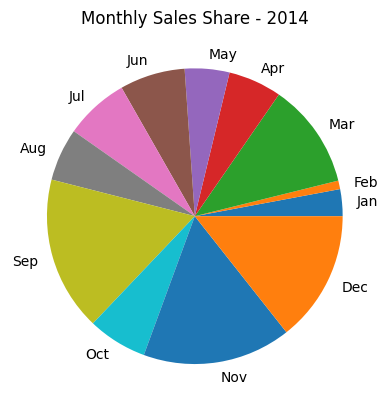

YearMonth
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2

In [46]:
df['date_column'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y', dayfirst=False)
df['Year'] = df['date_column'].dt.year
df['Month'] = df['date_column'].dt.month

df['YearMonth'] = df['date_column'].dt.to_period('M')

monthly_summary = df.groupby('YearMonth')['Sales'].sum()

data_2014 = monthly_summary[monthly_summary.index.year == 2014]

months = data_2014.index.strftime('%b')
sales = data_2014.values

sns.barplot(x=months, y=sales)
plt.title('Monthly Sales - 2014')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

plt.plot(months, sales, marker='o')
plt.title('Monthly Sales Trend - 2014')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()


plt.pie(sales, labels=months)
plt.title('Monthly Sales Share - 2014')
plt.show()

print(monthly_summary)


The bar chart shows the monthly sales trend best because the height of each bar makes it easy to compare sales between individual months. Although the line chart also shows the trend clearly, the bar chart makes differences in monthly sales easier to compare. The pie chart hides the trend because it focuses on each month's proportion of total sales rather than the chronological order and changes over time. Therefore, I would choose the bar chart, while the pie chart is the least suitable for showing a monthly trend.

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64


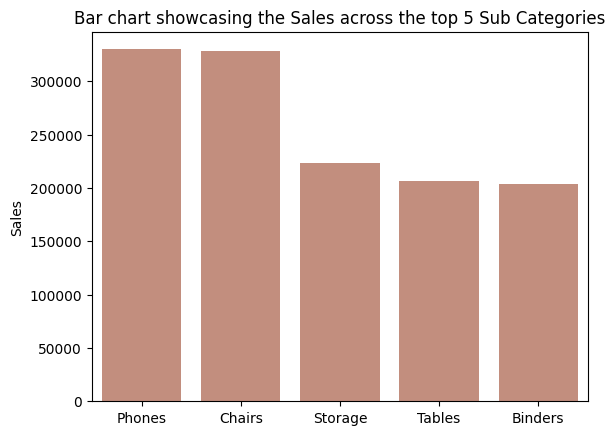

In [93]:
top_5 = df.groupby('Sub-Category')['Sales'].sum().nlargest(5)
names=top_5.index.tolist()
print(top_5)

plt.title("Bar chart showcasing the Sales across the top 5 Sub Categories")
sns.barplot(x=names, y=top_5, color="#cd8873")
plt.show()


I chose a bar chart because it makes it easy to compare total sales across the five sub-categories. A pie chart would be a weaker choice because similar-sized slices are difficult to compare accurately.

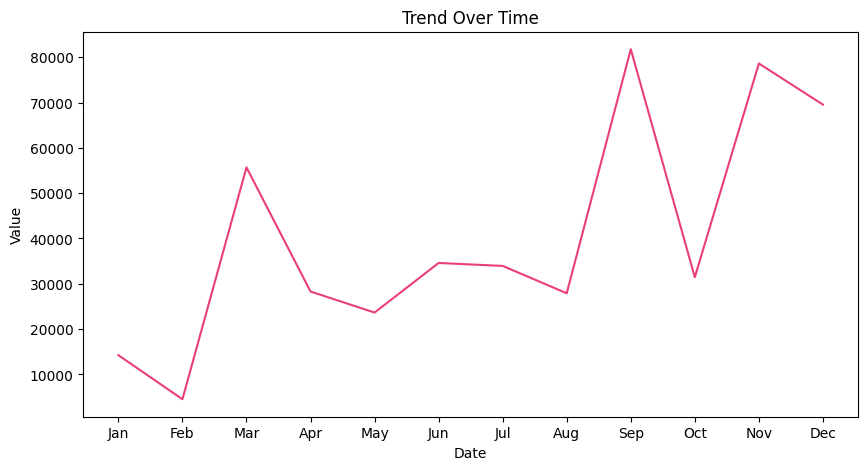

In [94]:
plt.figure(figsize=(10, 5))
sns.lineplot( x=months, y=sales, color="#e93e7a")

plt.title('Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

I chose a line chart because the months have a natural chronological order, and connecting the points clearly shows changes in sales over time. A pie chart would be a weak choice because it shows proportions rather than the direction or movement of a time series.

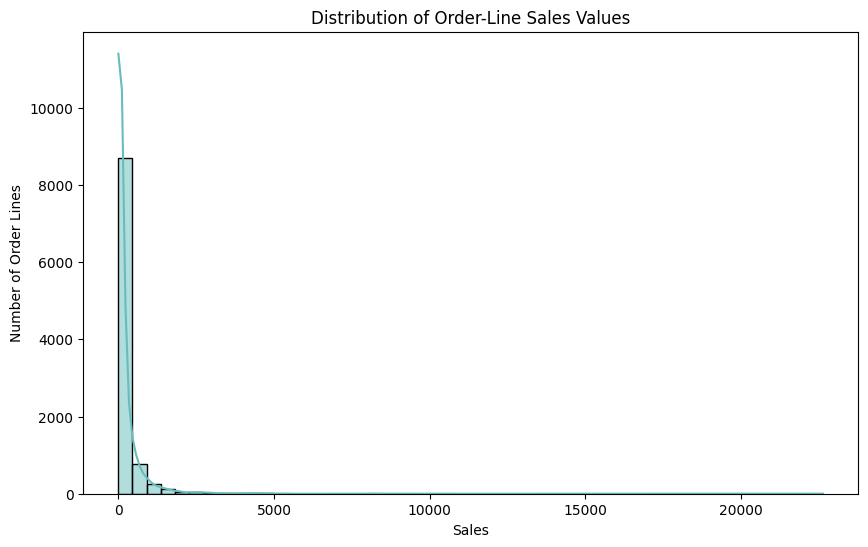

In [95]:

plt.figure(figsize=(10, 6))

sns.histplot(df['Sales'], bins=50, kde=True, color="#67bcbc")

plt.title('Distribution of Order-Line Sales Values')
plt.xlabel('Sales')
plt.ylabel('Number of Order Lines')

plt.show()


I chose a histogram because it shows how individual order-line sales values are distributed across different value ranges. A bar chart would be a weaker choice because sales values are continuous numerical data rather than separate categories.

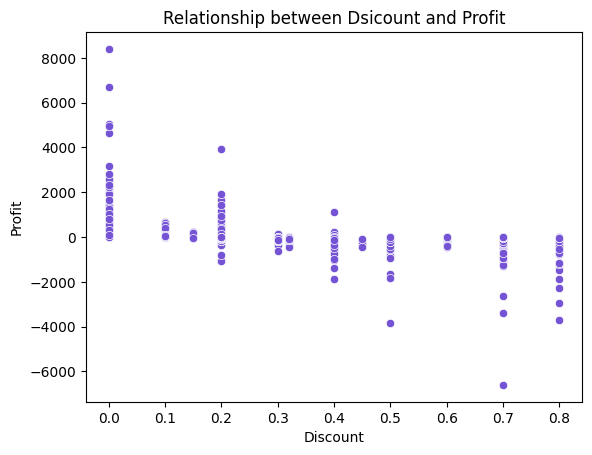

In [96]:
plt.title("Relationship between Dsicount and Profit")
sns.scatterplot(data=df, x="Discount", y="Profit", color="#7453d5")
plt.show()

I chose a scatter plot because both discount and profit are numerical variables, and the individual points show their relationship directly. A bar chart would be a weaker choice because it would require grouping the observations and could hide the variation in the raw data.

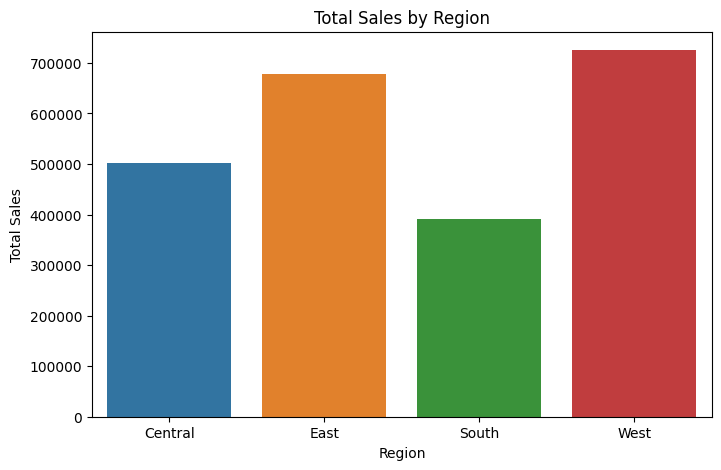

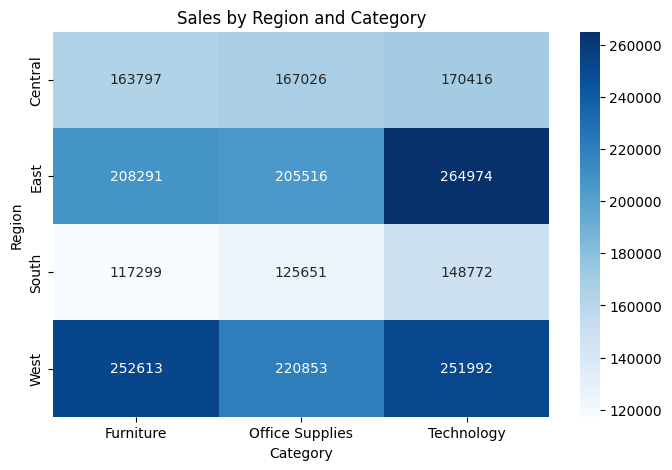

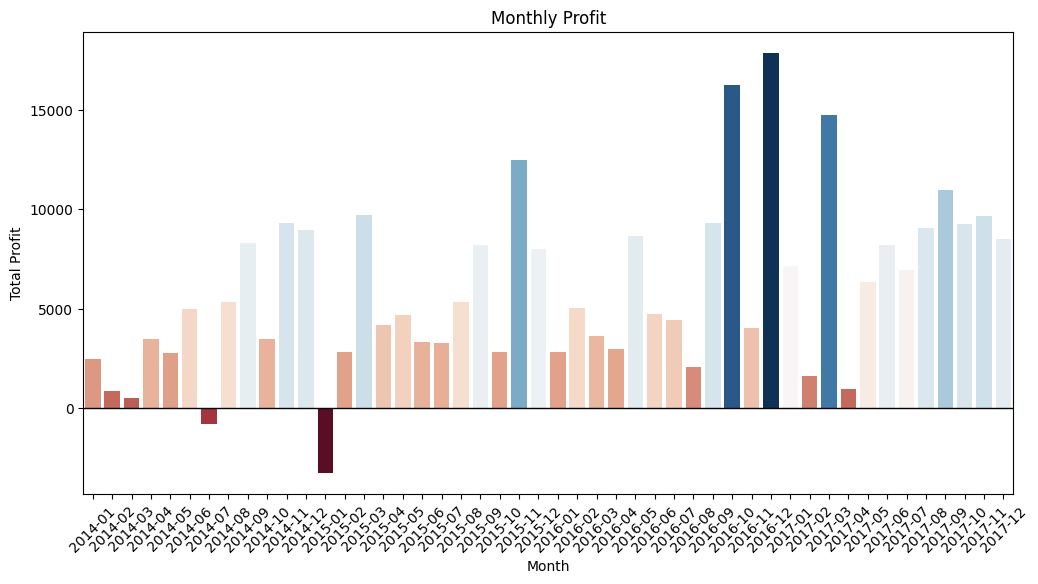

In [72]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=region_sales,
    x='Region',
    y='Sales',
    hue='Region',
    palette='tab10',
    legend=False
)

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()



region_category = df.pivot_table(
    index='Region',
    columns='Category',
    values='Sales',
    aggfunc='sum'
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    region_category,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title('Sales by Region and Category')
plt.xlabel('Category')
plt.ylabel('Region')
plt.show()

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%m/%d/%Y'
)

# Total profit by month
monthly_profit = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Profit']
      .sum()
      .reset_index()
)

monthly_profit['Order Date'] = monthly_profit['Order Date'].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_profit,
    x='Order Date',
    y='Profit',
    hue='Profit',
    palette='RdBu',
    legend=False
)

plt.axhline(0, color='black', linewidth=1)

plt.title('Monthly Profit')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)

plt.show()

In [75]:

from matplotlib.colors import to_rgb


def relative_luminance(rgb):
    """
    Calculate WCAG relative luminance for an RGB color.
    RGB values should be in the range 0-1.
    """
    rgb = np.array(rgb)

    # Convert sRGB to linear RGB
    rgb_linear = np.where(
        rgb <= 0.04045,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )

    # WCAG luminance formula
    return (
        0.2126 * rgb_linear[0] +
        0.7152 * rgb_linear[1] +
        0.0722 * rgb_linear[2]
    )


def contrast_ratio(color1, color2):
    """
    Calculate WCAG contrast ratio between two colors.
    Colors can be RGB tuples or matplotlib color names/hex values.
    """
    rgb1 = to_rgb(color1)
    rgb2 = to_rgb(color2)

    L1 = relative_luminance(rgb1)
    L2 = relative_luminance(rgb2)

    lighter = max(L1, L2)
    darker = min(L1, L2)

    return (lighter + 0.05) / (darker + 0.05)




Color 1: contrast = 4.82:1 -> PASS
Color 2: contrast = 2.53:1 -> FAIL
Color 3: contrast = 3.40:1 -> FAIL
Color 4: contrast = 5.02:1 -> PASS


In [77]:
# Set2 - Task 3(a)
print("TAB10")
palette = sns.color_palette('tab10', 4)

for i, color in enumerate(palette):
    ratio = contrast_ratio(color, 'white')
    print(f'Color {i+1}: {ratio:.2f}:1 → '
          f'{"PASS" if ratio >= 4.5 else "FAIL"}')


# Blues - Task 3(b)
print("\nBLUES")
palette = sns.color_palette('Blues', 4)

for i, color in enumerate(palette):
    ratio = contrast_ratio(color, 'white')
    print(f'Color {i+1}: {ratio:.2f}:1 → '
          f'{"PASS" if ratio >= 4.5 else "FAIL"}')


# RdBu - Task 3(c)
print("\nRDBU")
palette = sns.color_palette('RdBu', 11)

for i, color in enumerate(palette):
    ratio = contrast_ratio(color, 'white')
    print(f'Color {i+1}: {ratio:.2f}:1 → '
          f'{"PASS" if ratio >= 4.5 else "FAIL"}')


TAB10
Color 1: 4.82:1 → PASS
Color 2: 2.53:1 → FAIL
Color 3: 3.40:1 → FAIL
Color 4: 5.02:1 → PASS

BLUES
Color 1: 1.33:1 → FAIL
Color 2: 1.87:1 → FAIL
Color 3: 3.18:1 → FAIL
Color 4: 6.08:1 → PASS

RDBU
Color 1: 7.71:1 → PASS
Color 2: 4.71:1 → PASS
Color 3: 2.69:1 → FAIL
Color 4: 1.72:1 → FAIL
Color 5: 1.26:1 → FAIL
Color 6: 1.08:1 → FAIL
Color 7: 1.26:1 → FAIL
Color 8: 1.65:1 → FAIL
Color 9: 2.53:1 → FAIL
Color 10: 4.09:1 → FAIL
Color 11: 6.78:1 → PASS


   Sub-Category      Profit
0        Tables -17725.4811
1     Bookcases  -3472.5560
2      Supplies  -1189.0995
3     Fasteners    949.5182
4      Machines   3384.7569
5        Labels   5546.2540
6           Art   6527.7870
7     Envelopes   6964.1767
8   Furnishings  13059.1436
9    Appliances  18138.0054
10      Storage  21278.8264
11       Chairs  26590.1663
12      Binders  30221.7633
13        Paper  34053.5693
14  Accessories  41936.6357
15       Phones  44515.7306
16      Copiers  55617.8249


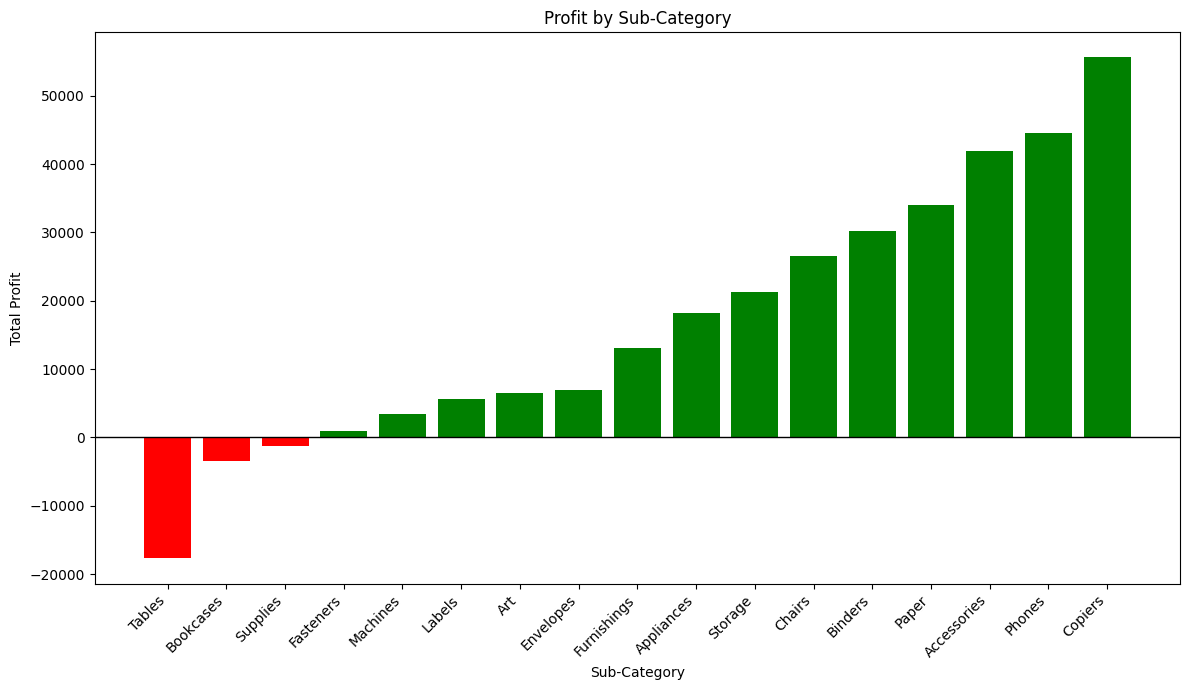

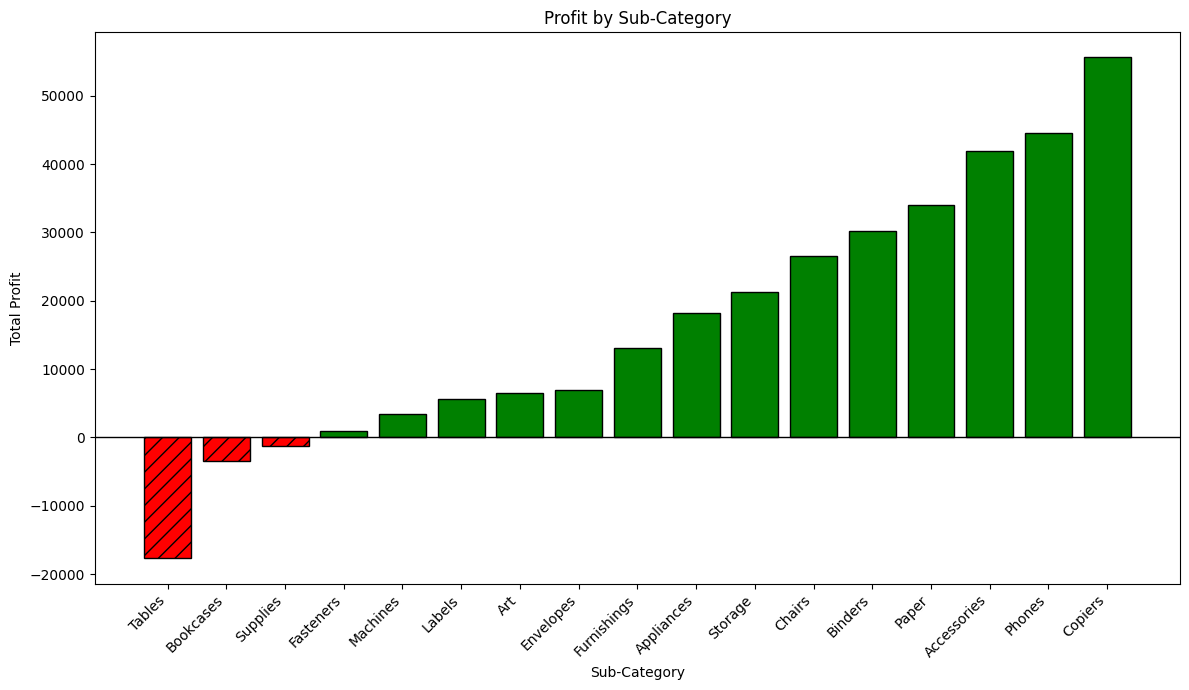

In [78]:
profit_subcategory = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values()
      .reset_index()
)

print(profit_subcategory)


import matplotlib.pyplot as plt

colors = [
    'red' if profit < 0 else 'green'
    for profit in profit_subcategory['Profit']
]

plt.figure(figsize=(12, 7))

plt.bar(
    profit_subcategory['Sub-Category'],
    profit_subcategory['Profit'],
    color=colors
)

plt.axhline(0, color='black', linewidth=1)

plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Save the original chart
plt.savefig('profit_before.png', dpi=300, bbox_inches='tight')

plt.show()


colors = [
    'red' if profit < 0 else 'green'
    for profit in profit_subcategory['Profit']
]

hatches = [
    '//' if profit < 0 else ''
    for profit in profit_subcategory['Profit']
]

plt.figure(figsize=(12, 7))

bars = plt.bar(
    profit_subcategory['Sub-Category'],
    profit_subcategory['Profit'],
    color=colors,
    edgecolor='black'
)

# Add hatching to loss bars
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

plt.axhline(0, color='black', linewidth=1)

plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Save fixed chart
plt.savefig('profit_after.png', dpi=300, bbox_inches='tight')

plt.show()




In [79]:
pip install pillow numpy matplotlib


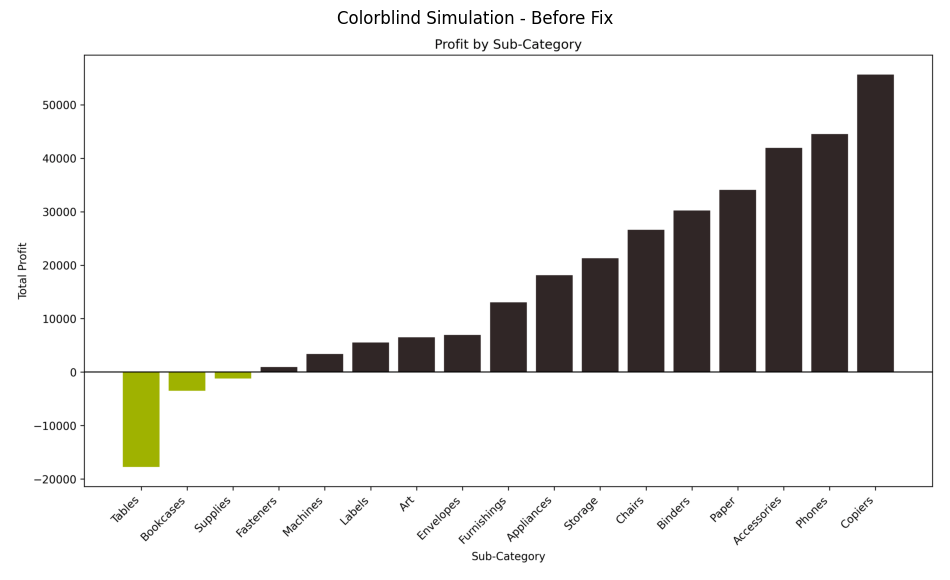

In [80]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


def simulate_colorblindness(image_path, deficiency="deuteranopia"):
    """
    Simulate common types of color vision deficiency.

    deficiency:
        'protanopia'  - red-blind
        'deuteranopia' - green-blind
        'tritanopia'  - blue-blind
    """

    img = Image.open(image_path).convert("RGB")
    img_array = np.asarray(img).astype(float) / 255.0

    # Color transformation matrices
    matrices = {
        "protanopia": np.array([
            [0.567, 0.433, 0.000],
            [0.558, 0.442, 0.000],
            [0.000, 0.242, 0.758]
        ]),

        "deuteranopia": np.array([
            [0.625, 0.375, 0.000],
            [0.700, 0.300, 0.000],
            [0.000, 0.300, 0.700]
        ]),

        "tritanopia": np.array([
            [0.950, 0.050, 0.000],
            [0.000, 0.433, 0.567],
            [0.000, 0.475, 0.525]
        ])
    }

    matrix = matrices[deficiency]

    # Apply transformation
    simulated = img_array @ matrix.T

    # Keep values between 0 and 1
    simulated = np.clip(simulated, 0, 1)

    return (simulated * 255).astype(np.uint8)


# ------------------------------------------------
# TEST YOUR ORIGINAL CHART
# ------------------------------------------------

original = "profit_before.png"

simulated = simulate_colorblindness(
    original,
    deficiency="deuteranopia"
)

# Save simulated image
Image.fromarray(simulated).save(
    "profit_before_simulated.png"
)

# Display
plt.figure(figsize=(12, 7))
plt.imshow(simulated)
plt.axis("off")
plt.title("Colorblind Simulation - Before Fix")
plt.show()


In [81]:
original = "profit_after.png"


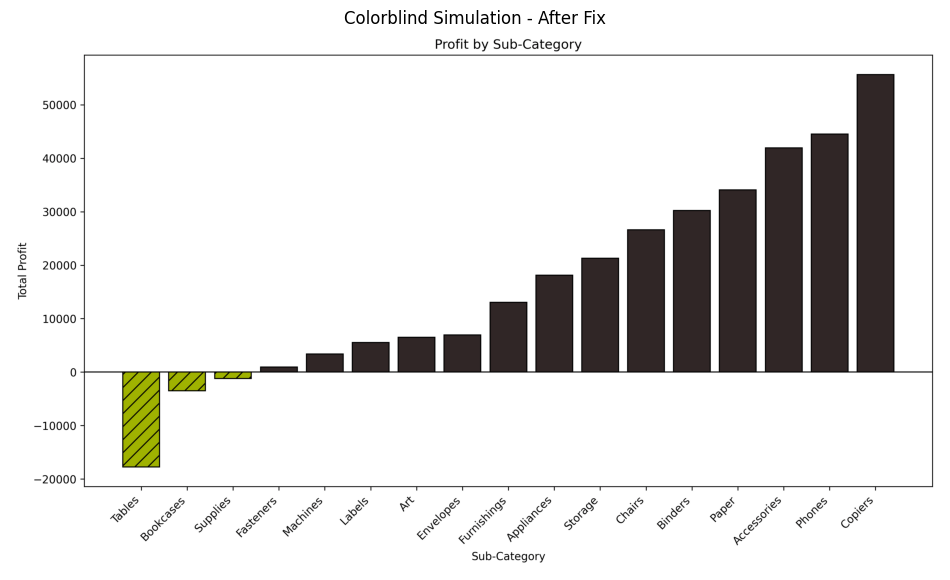

In [82]:
simulated = simulate_colorblindness(
    "profit_after.png",
    deficiency="deuteranopia"
)

Image.fromarray(simulated).save(
    "profit_after_simulated.png"
)

plt.figure(figsize=(12, 7))
plt.imshow(simulated)
plt.axis("off")
plt.title("Colorblind Simulation - After Fix")
plt.show()


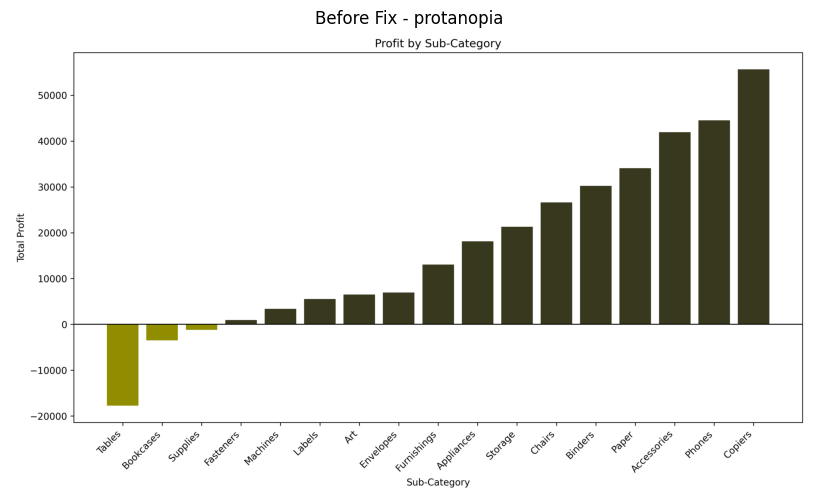

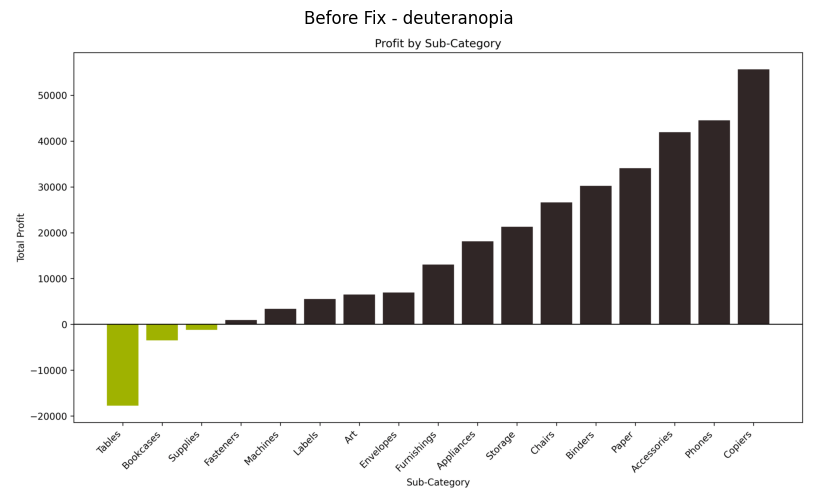

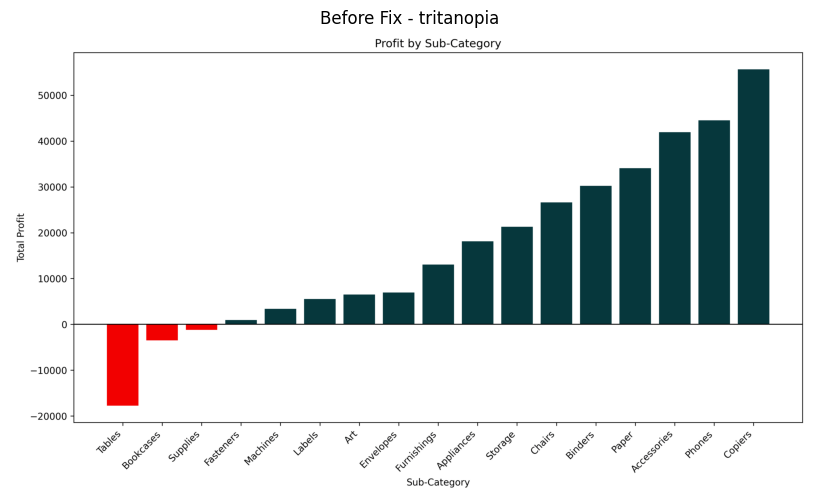

In [83]:
for deficiency in [
    "protanopia",
    "deuteranopia",
    "tritanopia"
]:

    simulated = simulate_colorblindness(
        "profit_before.png",
        deficiency=deficiency
    )

    Image.fromarray(simulated).save(
        f"profit_before_{deficiency}.png"
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(simulated)
    plt.axis("off")
    plt.title(f"Before Fix - {deficiency}")
    plt.show()


In [84]:
original = "profit_after.png"


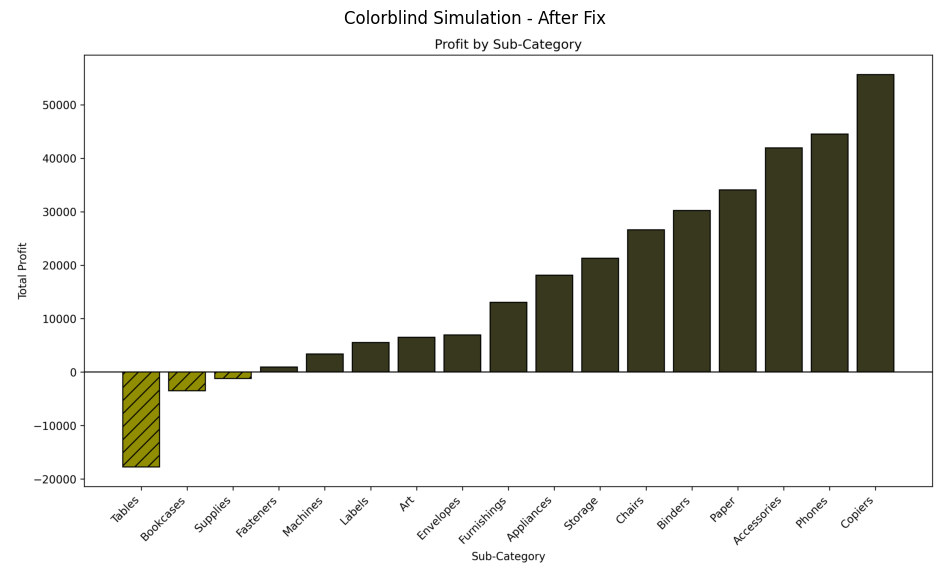

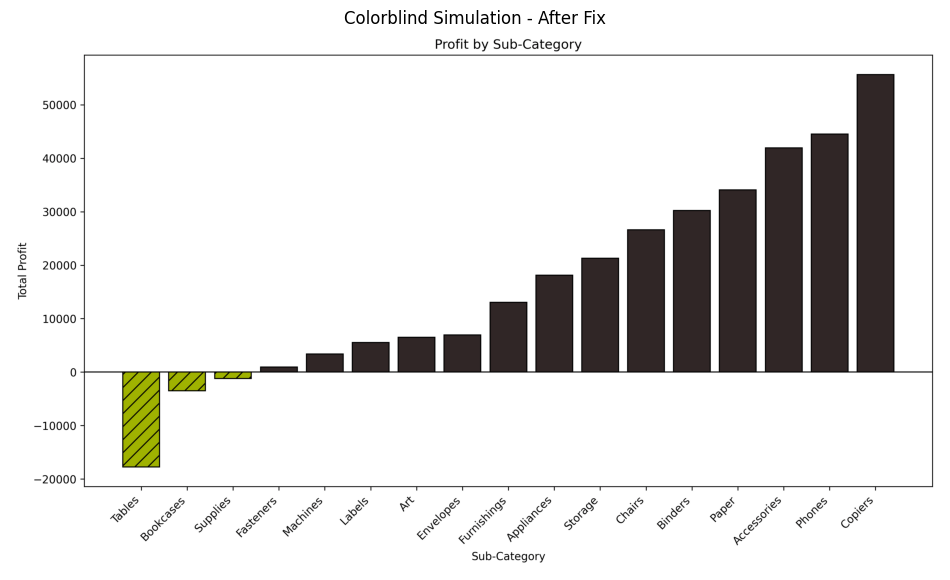

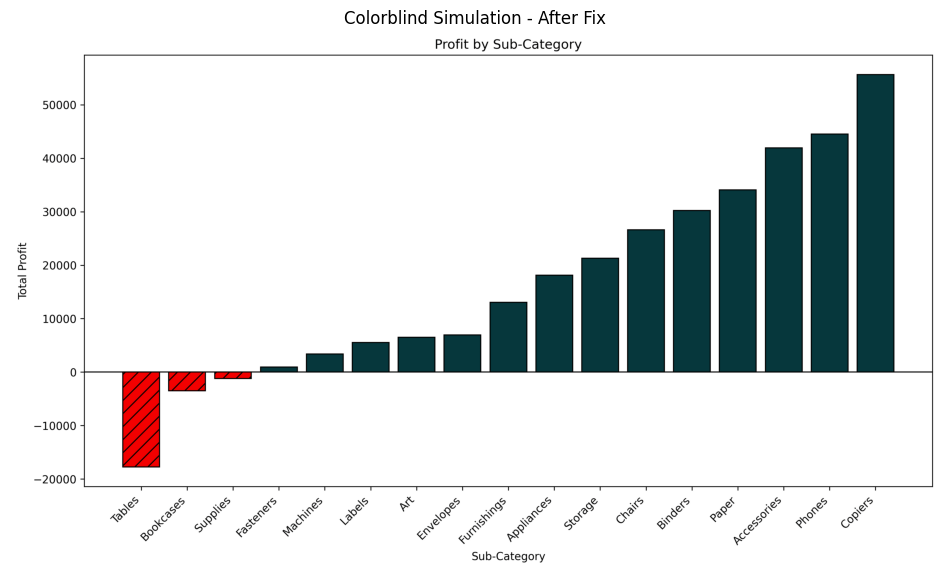

In [85]:
for deficiency in [
    "protanopia",
    "deuteranopia",
    "tritanopia"
]:

  simulated = simulate_colorblindness(
      "profit_after.png",
      deficiency=deficiency
  )

  Image.fromarray(simulated).save(
      "profit_after_simulated.png"
  )

  plt.figure(figsize=(12, 7))
  plt.imshow(simulated)
  plt.axis("off")
  plt.title("Colorblind Simulation - After Fix")
  plt.show()

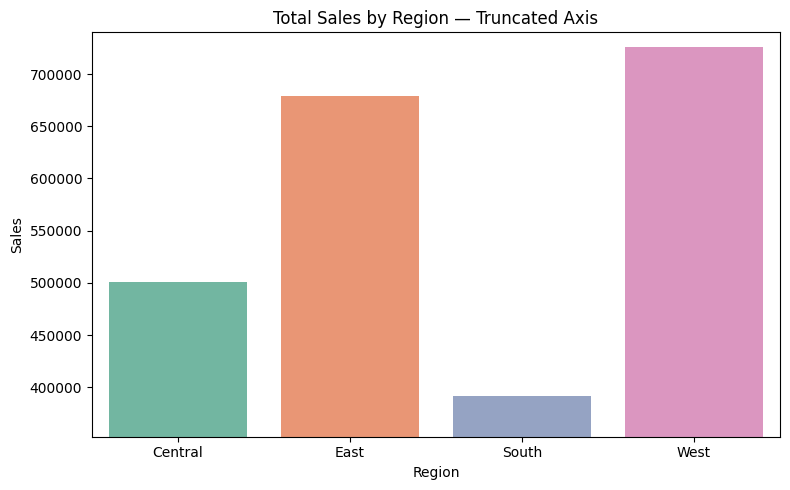

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=region_sales,
    x='Region',
    y='Sales',
    hue='Region',
    palette='Set2',
    legend=False
)

# TRUNCATED Y-AXIS
plt.ylim(
    region_sales['Sales'].min() * 0.90,
    region_sales['Sales'].max() * 1.02
)

plt.title('Total Sales by Region — Truncated Axis')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()


Distortion mechanism — truncated y-axis: The y-axis starts above zero, exaggerating the visual difference between regional sales totals.

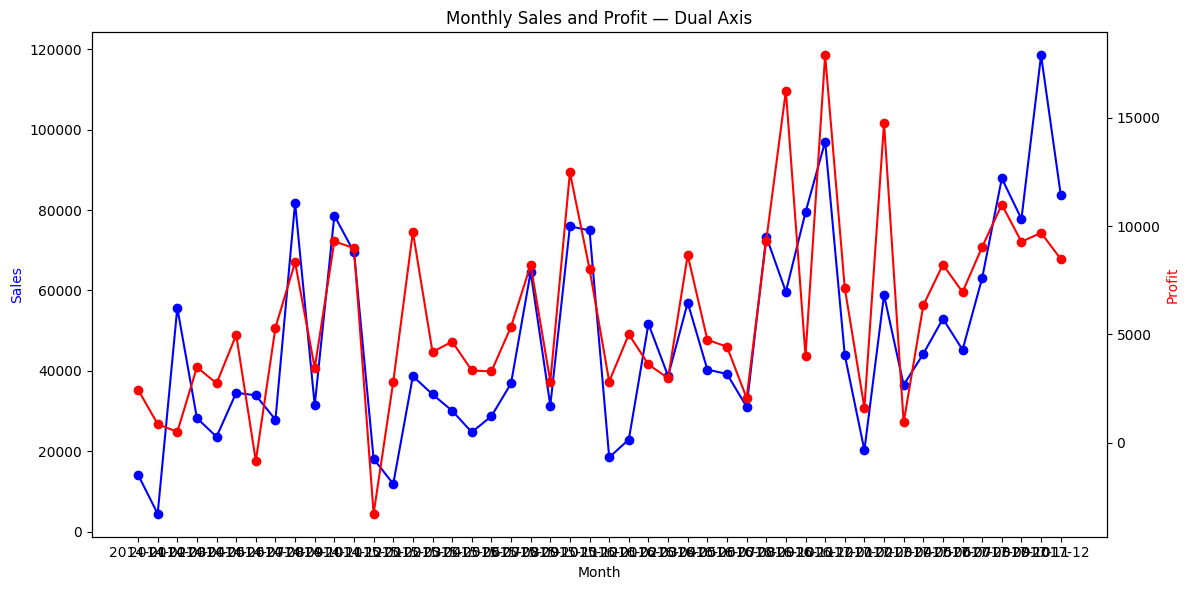

In [87]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%m/%d/%Y'
)

monthly_data = (
    df.groupby(df['Order Date'].dt.to_period('M'))
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum')
      )
      .reset_index()
)

monthly_data['Month'] = monthly_data['Order Date'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Sales
ax1.plot(
    monthly_data['Month'],
    monthly_data['Sales'],
    color='blue',
    marker='o'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Sales', color='blue')

# Second axis
ax2 = ax1.twinx()

ax2.plot(
    monthly_data['Month'],
    monthly_data['Profit'],
    color='red',
    marker='o'
)

ax2.set_ylabel('Profit', color='red')

plt.title('Monthly Sales and Profit — Dual Axis')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Distortion mechanism — dual-axis scale manipulation: Independent y-axis scales make two unrelated measures appear visually correlated even when their movements are not directly comparable.

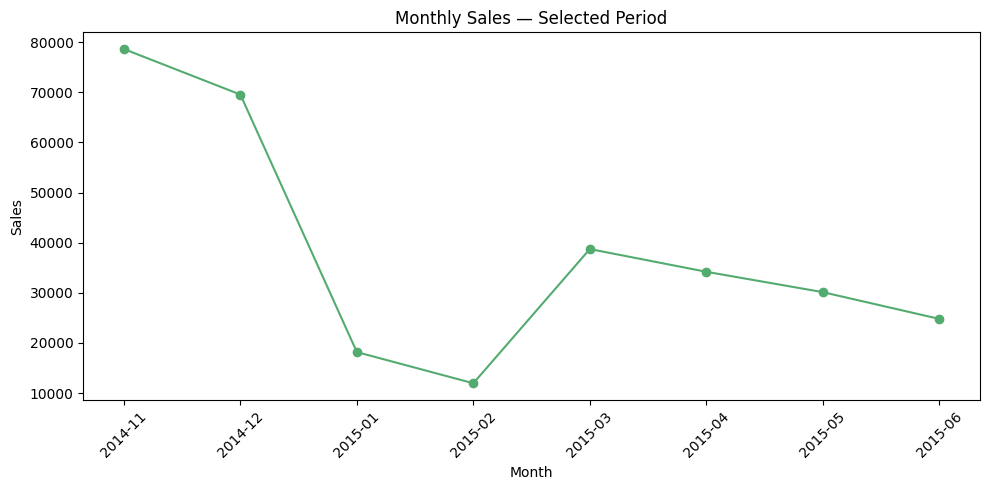

In [100]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
      .sum()
      .reset_index()
)

monthly_sales['Month'] = monthly_sales['Order Date'].astype(str)

# CHERRY-PICKED WINDOW
cherry_picked = monthly_sales.iloc[10:18]

plt.figure(figsize=(10, 5))

plt.plot(
    cherry_picked['Month'],
    cherry_picked['Sales'],
    marker='o',
    color="#54ab70"
)

plt.title('Monthly Sales — Selected Period')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Distortion mechanism — cherry-picking: Only a favorable portion of the time series is shown, hiding the surrounding trend and potentially misleading the viewer about the overall pattern.

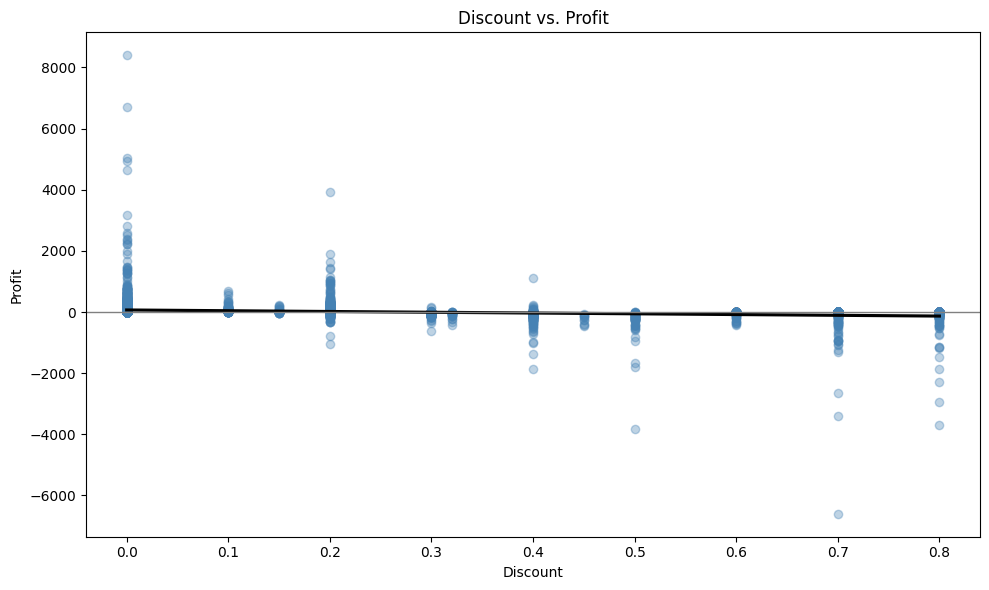

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter_kws={'alpha': 0.35, 'color': 'steelblue'},
    line_kws={'color': 'black'}
)

plt.axhline(0, color='gray', linewidth=1)

plt.title('Discount vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()


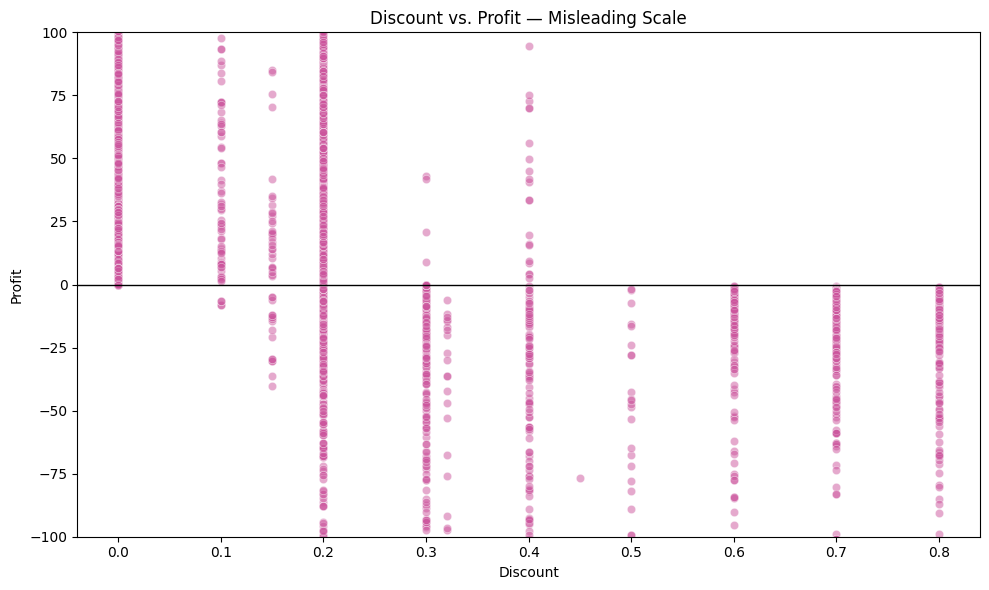

In [99]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    color='#cc559d',
    alpha=0.5
)

# DELIBERATELY MISLEADING
plt.ylim(-100, 100)

plt.axhline(0, color='black', linewidth=1)

plt.title('Discount vs. Profit — Misleading Scale')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()


Distortion mechanism — truncated y-axis: Restricting the profit axis to a narrow range hides extreme observations and exaggerates the apparent concentration of profits around zero.

Chart choice: I used a scatter plot because the question compares two continuous variables, discount and profit, at the individual order-line level. This preserves the raw observations and allows the relationship and variation to be seen directly.

Color choice: I used a single blue color with transparency because color is not needed to encode a third variable. The horizontal zero line provides a neutral reference for distinguishing positive and negative profit.

Accessibility: The chart does not rely on color to communicate the main relationship, and the zero-profit line provides an additional visual reference. I would also check text and line contrast against the background using the WCAG contrast-ratio test.